# Neal's Funnel

## Test for 2D

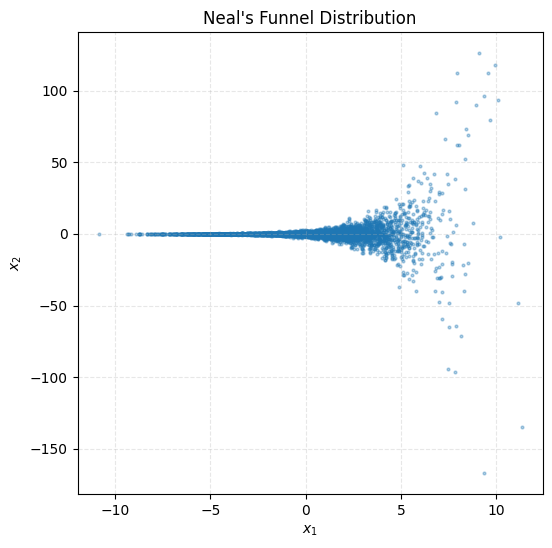

In [1]:
import jax
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt

# -------------------------------------------------
# Ground Truth Neal's Funnel Sampler
# -------------------------------------------------
def sample_funnel(key, n, sigma2=9.0):
    """
    Neal's Funnel distribution in D=2:
        x1 ~ Normal(0, sigma2)
        x2 | x1 ~ Normal(0, exp(x1/2))
    """
    # Sample x1
    key1, key2 = random.split(key)
    x1 = random.normal(key1, (n,)) * jnp.sqrt(sigma2)

    # Sample x2 conditional on x1
    std = jnp.exp(x1 / 2.0)         # funnel scaling
    x2 = random.normal(key2, (n,)) * std

    return jnp.stack([x1, x2], axis=1)


# -------------------------------------------------
# Example usage + visualization
# -------------------------------------------------
if __name__ == "__main__":
    rng = random.PRNGKey(0)
    samples = sample_funnel(rng, n=5000)

    x1 = samples[:,0]
    x2 = samples[:,1]

    plt.figure(figsize=(6,6))
    plt.scatter(x1, x2, s=4, alpha=0.35)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.title("Neal's Funnel Distribution")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()


In [9]:
# =========================================================
# PPO-RLFS for Neal's Funnel (annealed σ, proper log F/B)
# =========================================================
import jax
import jax.numpy as jnp
from jax import random, lax, jit, grad
import optax
from flax import linen as nn
from flax.training.train_state import TrainState
import numpy as np
jax.config.update("jax_enable_x64", True)

# =========================================================
# MMD metrics
# =========================================================
def pairwise_sq_dists(X, Y):
    X_norm = jnp.sum(X**2, axis=1, keepdims=True)
    Y_norm = jnp.sum(Y**2, axis=1, keepdims=True).T
    return X_norm + Y_norm - 2.0 * (X @ Y.T)

def rbf_kernel_matrix(X, Y, gamma):
    d2 = pairwise_sq_dists(X, Y)
    return jnp.exp(-gamma * d2)

def median_kernel_width(X, Y):
    Z = jnp.concatenate([X, Y], axis=0)
    d2 = pairwise_sq_dists(Z, Z)
    d2_flat = d2[jnp.triu_indices(d2.shape[0], k=1)]
    d2_flat = d2_flat[jnp.isfinite(d2_flat)]
    if d2_flat.size == 0:
        return 1.0
    med = jnp.median(jnp.sqrt(jnp.clip(d2_flat, 1e-6, 1e6)))
    med = jnp.maximum(med, 1e-3)
    sigma2 = med**2
    return 1.0 / (2.0 * sigma2)

def mmd_unbiased_rbf(X, Y):
    X = X[jnp.isfinite(X).all(axis=1)]
    Y = Y[jnp.isfinite(Y).all(axis=1)]
    n, m = X.shape[0], Y.shape[0]
    if n < 2 or m < 2:
        return jnp.nan
    gamma = median_kernel_width(X, Y)
    Kxx = rbf_kernel_matrix(X, X, gamma)
    Kyy = rbf_kernel_matrix(Y, Y, gamma)
    Kxy = rbf_kernel_matrix(X, Y, gamma)
    sum_Kxx = (jnp.sum(Kxx) - jnp.trace(Kxx)) / (n * (n - 1) + 1e-12)
    sum_Kyy = (jnp.sum(Kyy) - jnp.trace(Kyy)) / (m * (m - 1) + 1e-12)
    sum_Kxy = jnp.sum(Kxy) / (n * m + 1e-12)
    val = sum_Kxx + sum_Kyy - 2.0 * sum_Kxy
    return jnp.nan_to_num(val, nan=0.0, posinf=0.0, neginf=0.0)

# =========================================================
# Target (Neal’s Funnel)
# =========================================================
D = 2
SIGMA2 = 9.0
SIGMA = jnp.sqrt(SIGMA2)

def log_unnormalized_pi(x, sigma2=9.0):
    x1, rest = x[...,0], x[...,1:]
    Dloc = x.shape[-1]
    dminus1 = Dloc-1
    quad = jnp.sum(rest**2, axis=-1)
    cond = -0.5*jnp.exp(-x1)*(quad - dminus1*jnp.exp(x1))
    norm = -0.5*dminus1*x1
    prior = -0.5*(x1**2)/sigma2
    return prior+norm+cond

def sample_funnel(key, n, d=D, sigma2=SIGMA2):
    key1, key2 = random.split(key)
    x1 = random.normal(key1, (n,1))*jnp.sqrt(sigma2)
    s = jnp.exp(x1)
    eps = random.normal(key2, (n,d-1))
    rest = eps*jnp.sqrt(s)
    return jnp.concatenate([x1,rest],axis=1)

# =========================================================
# Env step (variable σ, proper logF/logB)
# =========================================================
EPS = 1e-8

def env_step(key, x_t, mu_t, sigma_act):
    """Forward/Backward pair with given σ."""
    B, D = x_t.shape
    eps = random.normal(key, (B, D))
    x_next = x_t + mu_t + sigma_act * eps

    sigma2_act = sigma_act**2

    # ---- log F ----
    mean_f = x_t + mu_t
    diff_f = (x_next - mean_f) / sigma_act
    logF = -0.5 * jnp.sum(diff_f**2, axis=-1)

    # ---- log B ----
    mean_b = jnp.sqrt(1 - sigma2_act) * x_next
    diff_b = (x_t - mean_b) / sigma_act
    logB = -0.5 * jnp.sum(diff_b**2, axis=-1)

    # ---- reward ----
    r_t = jnp.clip(logB - logF, -20.0, 20.0)
    a_t = x_next - x_t

    diff_p = a_t - mu_t
    logp = -0.5 * jnp.sum(diff_p**2, axis=-1)
    return x_next, a_t, logp, r_t

# =========================================================
# Actor / Critic
# =========================================================
class Actor(nn.Module):
    D: int
    hidden: int = 256
    @nn.compact
    def __call__(self, x, t):
        h = jnp.concatenate([x, t], axis=-1)
        h = nn.tanh(nn.Dense(self.hidden,
                             kernel_init=nn.initializers.normal(1e-1),
                             bias_init=nn.initializers.zeros)(h))
        h = nn.tanh(nn.Dense(self.hidden,
                             kernel_init=nn.initializers.normal(1e-1),
                             bias_init=nn.initializers.zeros)(h))
        out = nn.Dense(self.D,
                       kernel_init=nn.initializers.normal(1e-3),
                       bias_init=nn.initializers.zeros)(h)
        return out


class Critic(nn.Module):
    hidden:int=256
    @nn.compact
    def __call__(self,x,t_frac):
        h=jnp.concatenate([x,t_frac],axis=-1)
        h=nn.tanh(nn.Dense(self.hidden)(h))
        h=nn.tanh(nn.Dense(self.hidden)(h))
        v=nn.Dense(1)(h)
        return v.squeeze(-1)

class ActorState(TrainState): pass
class CriticState(TrainState): pass

# =========================================================
# Rollout & GAE
# =========================================================
def terminal_reward(x_T, tau=1.): return (1./tau)*log_unnormalized_pi(x_T)

def rollout_episode(rng, actor_params, critic_params,
                    actor_apply, critic_apply,
                    BATCH, D, T, tau, sigma_act):
    rng, key_init = random.split(rng)
    x0 = 10.0 * random.normal(key_init, (BATCH, D))

    def body(carry, t_idx):
        rng, x_t = carry
        t_frac = jnp.ones((BATCH,1)) * (t_idx / T)
        mu_t = actor_apply(actor_params, x_t, t_frac)
        rng, step_key = random.split(rng)
        x_next, a_t, logp, r_t = env_step(step_key, x_t, mu_t, sigma_act)
        v_t = critic_apply(critic_params, x_t, t_frac)
        return (rng, x_next), dict(
            x_t=x_t, a_t=a_t, logprob=logp,
            value=v_t, t_frac=t_frac.squeeze(-1),
            rewards=r_t/tau
        )

    (rng, x_T), traj = lax.scan(body, (rng, x0), jnp.arange(T))
    rew_T = terminal_reward(x_T, tau)
    rewards = jnp.stack(traj["rewards"], axis=0)
    rewards = rewards.at[-1].add(rew_T)
    v_T = critic_apply(critic_params, x_T, jnp.ones((BATCH,1)))
    traj["v_T"] = v_T
    traj["rewards"] = rewards
    traj["x_T"] = x_T
    traj["terminal_bonus"] = rew_T
    return rng, traj

def compute_gae(traj, gamma=1., lam=0.95):
    r, v, v_T = traj["rewards"], traj["value"], traj["v_T"]
    T_len, B = r.shape
    def backward(carry, t_idx):
        gae, next_v = carry
        delta = r[t_idx] + gamma * next_v - v[t_idx]
        gae_t = delta + gamma * lam * gae
        return (gae_t, v[t_idx]), gae_t
    (_, _), adv_rev = lax.scan(backward, (jnp.zeros((B,)), v_T),
                               jnp.arange(T_len-1, -1, -1))
    adv = jnp.flip(adv_rev, axis=0)
    returns = adv + v
    return adv, returns

# =========================================================
# PPO loss
# =========================================================
def gaussian_logprob(mu, a, sigma_act):
    diff = (a - mu) / sigma_act
    quad = -0.5 * jnp.sum(diff**2, axis=-1)
    return quad

def ppo_loss(actor_params, critic_params, batch,
             actor_apply, critic_apply, sigma_act,
             clip_eps=0.2, vf_coef=0.5, entropy_coef=0.01):
    x_t, t_frac, a_t, old_lp, adv_t, ret_t = (
        batch["x_t"], batch["t_frac"], batch["a_t"],
        batch["logprob"], batch["adv"], batch["ret"]
    )
    mu = actor_apply(actor_params, x_t, t_frac[:, None])
    new_lp = gaussian_logprob(mu, a_t, sigma_act)
    ratio = jnp.exp(new_lp - old_lp)
    adv_norm = (adv_t - jnp.mean(adv_t)) / (jnp.std(adv_t) + 1e-8)
    s1 = ratio * adv_norm
    s2 = jnp.clip(ratio, 1 - clip_eps, 1 + clip_eps) * adv_norm
    actor_obj = -jnp.mean(jnp.minimum(s1, s2))
    v_pred = critic_apply(critic_params, x_t, t_frac[:, None])
    v_loss = jnp.mean((ret_t - v_pred)**2)
    dim = a_t.shape[-1]
    entropy = 0.5 * jnp.mean(dim * (1. + jnp.log(2*jnp.pi*(sigma_act**2))))
    total = actor_obj + vf_coef*v_loss - entropy_coef*entropy
    aux = dict(actor_loss=actor_obj, critic_loss=v_loss,
               ratio=jnp.mean(ratio), entropy=entropy)
    return total, aux
# ---------- Elite warmup helpers (add above train_funnel_ppo) ----------
def _build_elite_dataset(traj, term_scores, top_frac=0.3):
    """
    Select top 'top_frac' episodes by terminal score and return
    per-step (x_t, t_frac, dx) flattened over time and selected episodes.
    traj fields:
      x_t:      (T, B, D)
      a_t:      (T, B, D)   # equals x_{t+1} - x_t
      t_frac:   (T, B)
    term_scores: (B,)
    """
    T, B, D = traj["x_t"].shape
    k = max(1, int(B * top_frac))
    elite_idx = jnp.argsort(term_scores)[-k:]           # top-K episodes

    x_t  = traj["x_t"][:, elite_idx, :].reshape(T * k, D)
    t_fr = traj["t_frac"][:, elite_idx].reshape(T * k)
    dx   = traj["a_t"][:, elite_idx, :].reshape(T * k, D)
    return x_t, t_fr, dx, k

def _bc_train_actor(rng, actor_state, x_t, t_frac, dx, sigma_now,
                    epochs=5, batch_size=4096, lr=5e-4, l2=1e-6):
    """
    Behavior cloning: regress mu_\theta(t, x_t) to dx with Gaussian MLE.
    Uses fixed sigma_now in the loss (you can swap to learnable sigma later).
    """
    opt = optax.adamw(lr, weight_decay=l2)
    params = actor_state.params
    opt_state = opt.init(params)

    def loss_fn(p, xb, tb, db):
        mu = actor_state.apply_fn(p, xb, tb[:, None])            # (N,D)
        resid = db - mu
        # NLL up to const: ||resid||^2 / (2 sigma^2)
        per = jnp.sum(resid**2, axis=-1) / (2.0 * (sigma_now**2) + 1e-8)
        return jnp.mean(per)

    @jax.jit
    def step(p, ostate, xb, tb, db):
        (loss, grads) = jax.value_and_grad(loss_fn)(p, xb, tb, db)
        updates, ostate = opt.update(grads, ostate, p)
        p = optax.apply_updates(p, updates)
        return p, ostate, loss

    N = x_t.shape[0]
    for ep in range(epochs):
        rng, key = random.split(rng)
        perm = random.permutation(key, N)
        for i in range(0, N, batch_size):
            sel = perm[i:i+batch_size]
            params, opt_state, _ = step(params, opt_state,
                                        x_t[sel], t_frac[sel], dx[sel])

    return actor_state.replace(params=params)

# ---------- Drop-in replacement for train_funnel_ppo ----------
def train_funnel_ppo(rng_key=random.PRNGKey(0), D=D, BATCH=2000, T=100,
                     actor_lr=1e-5, critic_lr=1e-6, NITER=1000, MINIBATCH=500,
                     sigma_start=0.2, sigma_end=0.2, decay=0.995,
                     # --- elite warmup knobs ---
                     elite_rounds=10,        # number of IL/CEM warmup rounds
                     elite_frac=0.05,        # keep top 30% episodes by terminal score
                     bc_epochs=5,           # BC epochs per round
                     bc_lr=5e-4):
    actor, critic = Actor(D), Critic()
    rng_key, key_a, key_c, key_ref = random.split(rng_key, 4)
    dummy_x = jnp.zeros((1, D)); dummy_t = jnp.zeros((1, 1))
    actor_params = actor.init(key_a, dummy_x, dummy_t)
    critic_params = critic.init(key_c, dummy_x, dummy_t)
    actor_state = ActorState.create(apply_fn=actor.apply, params=actor_params,
                                    tx=optax.adam(actor_lr))
    critic_state = CriticState.create(apply_fn=critic.apply, params=critic_params,
                                      tx=optax.adam(critic_lr))
    ref_samples = sample_funnel(key_ref, 4000, d=D)

    # ---- σ annealing schedule ----
    def sigma_schedule(it, sigma_start=sigma_start, sigma_end=sigma_end, decay=0.995):
        return float(sigma_end + (sigma_start - sigma_end) * (decay ** it))

    # Return both (flattened batch) and raw traj for elites
    @jit
    def do_rollout(rng, a_params, c_params, sigma_now):
        rng, traj = rollout_episode(rng, a_params, c_params,
                                    actor.apply, critic.apply,
                                    BATCH, D, T, 1.0, sigma_now)
        adv, ret = compute_gae(traj)
        batch = dict(
            x_t=traj["x_t"].reshape(T*BATCH, D),
            a_t=traj["a_t"].reshape(T*BATCH, D),
            t_frac=traj["t_frac"].reshape(T*BATCH),
            logprob=traj["logprob"].reshape(T*BATCH),
            adv=adv.reshape(T*BATCH),
            ret=ret.reshape(T*BATCH)
        )
        # also return raw fields for elite selection (time, batch kept separate)
        raw = dict(
            x_t=traj["x_t"],           # (T,B,D)
            a_t=traj["a_t"],           # (T,B,D)
            t_frac=traj["t_frac"],     # (T,B)
        )
        term = traj["terminal_bonus"]  # (B,)
        x_T = traj["x_T"]              # (B,D)
        return rng, batch, raw, x_T, term

    @jit
    def ppo_update(a_state, c_state, batch, sigma_now):
        def l_actor(p):
            l, aux = ppo_loss(p, c_state.params, batch,
                              a_state.apply_fn, c_state.apply_fn, sigma_now)
            return l, aux
        def l_critic(p):
            _, aux = ppo_loss(a_state.params, p, batch,
                              a_state.apply_fn, c_state.apply_fn, sigma_now)
            return aux["critic_loss"], aux
        a_grads, a_aux = jax.grad(l_actor, has_aux=True)(a_state.params)
        c_grads, c_aux = jax.grad(l_critic, has_aux=True)(c_state.params)
        a_state = a_state.apply_gradients(grads=a_grads)
        c_state = c_state.apply_gradients(grads=c_grads)
        aux = {**a_aux, **c_aux}
        return a_state, c_state, aux

    # =========================
    # Phase 0: Elite warmup (IL)
    # =========================
    if elite_rounds > 0:
        for r in range(elite_rounds):
            # Use early sigma (more exploration) during warmup
            sigma_now = sigma_schedule(1)  # close to sigma_start
            rng_key, batch_wu, traj_raw, x_T, term_scores = do_rollout(
                rng_key, actor_state.params, critic_state.params, sigma_now
            )
            # Build elite dataset
            x_e, t_e, dx_e, k = _build_elite_dataset(traj_raw, term_scores, top_frac=elite_frac)
            # Safety: if very small, skip this round
            if x_e.shape[0] < 8:
                print(f"[Warmup {r+1}/{elite_rounds}] too few elites; skipping.")
                continue
            # Behavior clone on elites
            actor_state = _bc_train_actor(rng_key, actor_state,
                                          x_e, t_e, dx_e,
                                          sigma_now,
                                          epochs=bc_epochs, lr=bc_lr)
            # Small telemetry
            mmd2_val = float(mmd_unbiased_rbf(x_T[:2000], ref_samples[:2000]))
            print(f"[Warmup {r+1}/{elite_rounds}] elites={k}/{BATCH} "
                  f"| σ≈{sigma_now:.3f} | MMD²≈{mmd2_val:.3e}")

    # =========================
    # Phase 1: Normal PPO (your loop)
    # =========================
    for it in range(1, NITER + 1):
        sigma_now = sigma_schedule(it)
        rng_key, batch, traj_raw, x_T, logpi_T = do_rollout(
            rng_key, actor_state.params, critic_state.params, sigma_now
        )

        # Standard minibatch PPO
        N = batch["x_t"].shape[0]
        idx = jnp.arange(N)
        for _ in range(4):
            for start in range(0, N, MINIBATCH):
                mb_idx = idx[start:start+MINIBATCH]
                mb = {k: v[mb_idx] for k, v in batch.items()}
                actor_state, critic_state, aux = ppo_update(actor_state, critic_state, mb, sigma_now)

        if it % 100 == 0 or it in (1, 2, 3):
            print(f"[{it:04d}] σ={sigma_now:.3f} | actor={aux['actor_loss']:.3f} "
                  f"critic={aux['critic_loss']:.3f} ent={aux['entropy']:.3f}")
            model_eval = x_T[:2000]
            ref_eval   = ref_samples[:2000]
            mmd2_val = float(mmd_unbiased_rbf(model_eval, ref_eval))
            x1_mean = float(jnp.mean(model_eval[:, 0]))
            rest_var_mean = float(jnp.mean(jnp.var(model_eval[:, 1:], axis=0)))
            print(f"   ↳ MMD²={mmd2_val:.4e} | E[x1]={x1_mean:.3f} | mean Var(rest)={rest_var_mean:.3f}")
            xq1, xq2, xq3 = jnp.percentile(model_eval[:, 0], jnp.array([25, 50, 75]))
            print(f"   ↳ x1 percentile: {xq1:.1f}, {xq2:.1f}, {xq3:.1f}")
            below_mask = model_eval[:, 0] < 0
            above_mask = model_eval[:, 0] >= 0
            if jnp.any(below_mask) and jnp.any(above_mask):
                var_below = jnp.mean(jnp.var(model_eval[below_mask][:, 1:], axis=0))
                var_above = jnp.mean(jnp.var(model_eval[above_mask][:, 1:], axis=0))
                print(f"   ↳ Var(rest | x1<0)={float(var_below):.3f} | Var(rest | x1>0)={float(var_above):.3f}\n")
            else:
                print("   ↳ not enough samples on one side of x1=0 to compute conditional variances.")

    return actor_state, critic_state

if __name__ == "__main__":
    actor_state, crtiic_state = train_funnel_ppo(BATCH=2000, T=72,
                     actor_lr=3e-5, critic_lr=3e-5,
                     NITER=1000, MINIBATCH=5000, sigma_start=0.1,
                     sigma_end=0.1, decay=0.999)


[Warmup 1/10] elites=100/2000 | σ≈0.100 | MMD²≈1.997e-01
[Warmup 2/10] elites=100/2000 | σ≈0.100 | MMD²≈1.508e-01
[Warmup 3/10] elites=100/2000 | σ≈0.100 | MMD²≈1.047e-01
[Warmup 4/10] elites=100/2000 | σ≈0.100 | MMD²≈8.301e-02
[Warmup 5/10] elites=100/2000 | σ≈0.100 | MMD²≈3.914e-02
[Warmup 6/10] elites=100/2000 | σ≈0.100 | MMD²≈3.135e-02
[Warmup 7/10] elites=100/2000 | σ≈0.100 | MMD²≈1.890e-02
[Warmup 8/10] elites=100/2000 | σ≈0.100 | MMD²≈1.585e-02
[Warmup 9/10] elites=100/2000 | σ≈0.100 | MMD²≈1.213e-02
[Warmup 10/10] elites=100/2000 | σ≈0.100 | MMD²≈1.635e-02
[0001] σ=0.100 | actor=0.007 critic=120399485455122382848.000 ent=-1.767
   ↳ MMD²=1.3973e-02 | E[x1]=-0.779 | mean Var(rest)=1.320
   ↳ x1 percentile: -2.6, -0.8, 1.2
   ↳ Var(rest | x1<0)=0.994 | Var(rest | x1>0)=1.848

[0002] σ=0.100 | actor=0.007 critic=1740301189081531940864.000 ent=-1.767
   ↳ MMD²=1.5582e-02 | E[x1]=-0.664 | mean Var(rest)=1.063
   ↳ x1 percentile: -2.8, -0.7, 1.4
   ↳ Var(rest | x1<0)=0.765 | Var(rest

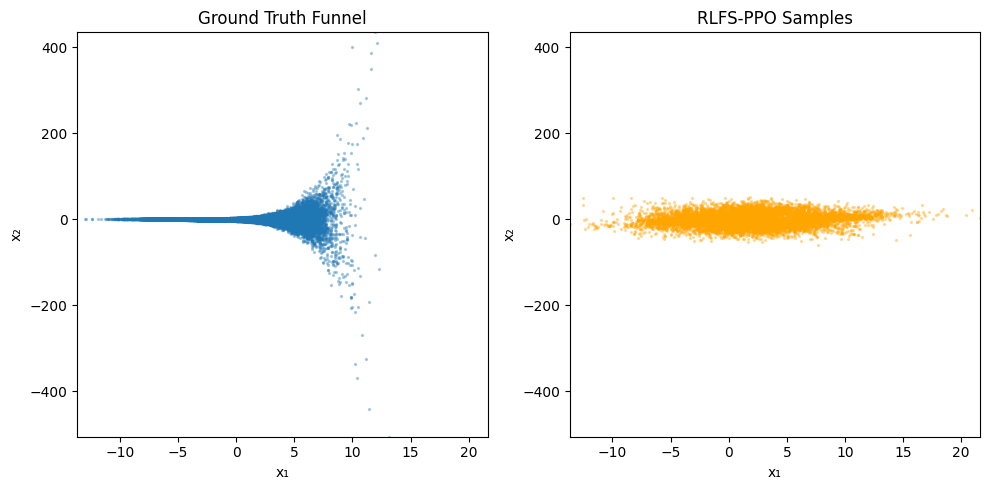

In [10]:
import matplotlib.pyplot as plt

def generate_samples(rng_key, actor_state, D=5, T=50, N=2000, x0_scale=10.0):
    """Generate final samples x_T from trained PPO-RLFS actor."""
    actor_apply = actor_state.apply_fn
    params = actor_state.params

    rng_key, key_init = random.split(rng_key)
    x0 = x0_scale * random.normal(key_init, (N, D))

    def body(carry, t_idx):
        rng, x_t = carry
        rng, step_key = random.split(rng)
        t_frac = jnp.ones((N, 1)) * (t_idx / T)
        mu_t = actor_apply(params, x_t, t_frac)
        eps = random.normal(step_key, (N, D))
        x_next = x_t + mu_t + 0.1 * eps
        return (rng, x_next), x_next

    (_, x_T_seq) = lax.scan(body, (rng_key, x0), jnp.arange(T))
    x_T = x_T_seq[-1]
    return x_T

x_T = generate_samples(random.PRNGKey(0), actor_state, D=D, T=50, N=8000)

def sample_funnel_2d(key, n=10000, sigma2=9.0):
    key1, key2 = jax.random.split(key)
    x1 = jax.random.normal(key1, (n,)) * jnp.sqrt(sigma2)
    x2 = jax.random.normal(key2, (n,)) * jnp.exp(0.5 * x1)
    return jnp.stack([x1, x2], axis=1)

samples_ref = sample_funnel_2d(random.PRNGKey(0), n=80000)
plt.figure(figsize=(10,5))

# Determine global axis limits
x1_all = np.concatenate([np.array(samples_ref[:,0]), np.array(x_T[:,0])])
x2_all = np.concatenate([np.array(samples_ref[:,1]), np.array(x_T[:,1])])
x1_min, x1_max = np.min(x1_all), np.max(x1_all)
x2_min, x2_max = np.min(x2_all), np.max(x2_all)

# left plot
plt.subplot(1,2,1)
plt.scatter(np.array(samples_ref[:,0]), np.array(samples_ref[:,1]),
            s=2, alpha=0.3, label="True Funnel")
plt.title("Ground Truth Funnel")
plt.xlabel("x₁"); plt.ylabel("x₂")
plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)

# right plot
plt.subplot(1,2,2)
plt.scatter(np.array(x_T[:,0]), np.array(x_T[:,1]),
            s=2, alpha=0.3, label="RLFS Samples", color='orange')
plt.title("RLFS-PPO Samples")
plt.xlabel("x₁"); plt.ylabel("x₂")
plt.xlim(x1_min, x1_max)
plt.ylim(x2_min, x2_max)

plt.tight_layout()
plt.show()
